In [37]:
import numpy as np
import pandas as pd

In [40]:
df = pd.read_csv('Social_Network_Ads.csv')

In [41]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [42]:
df = df[['Age', 'EstimatedSalary', 'Purchased']]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [48]:
np.round(df[['Age', 'EstimatedSalary']].describe())

,Age,EstimatedSalary
count,400.0,400.0
mean,38.0,69742.0
std,10.0,34097.0
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70000.0
75%,46.0,88000.0
max,60.0,150000.0


In [49]:
# splitting train, test data
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(df[['Age', 'EstimatedSalary']], df['Purchased'], test_size = 0.2, random_state = 24)

In [53]:
X_train.head()

,Age,EstimatedSalary
105,21,72000
17,45,26000
64,59,83000
349,38,61000
116,35,75000


In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()
# fitting the tarin data only(test data should not be fitted) to learn parameters
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [58]:
X_train_scale = scaler.transform(X_train)
X_test_scale = scaler.transform(X_test)

In [67]:
X_train_scale

array([[-1.61164262,  0.08633265],
       [ 0.68984777, -1.30102171],
       [ 2.03238384,  0.4180913 ],
       [ 0.01857974, -0.245426  ],
       [-0.26910656,  0.17681228],
       [ 0.21037061, -0.36606551],
       [-0.74858373,  0.53873081],
       [-0.84447916,  0.17681228],
       [-1.13216546, -1.57246061],
       [ 0.40216147,  1.17208823],
       [ 0.21037061, -0.12478649],
       [ 0.30626604, -0.18510625],
       [-0.17321113, -0.27558588],
       [ 0.30626604, -1.1803822 ],
       [-0.46089743, -1.15022232],
       [-0.26910656,  0.65937032],
       [-1.89932892, -0.75814392],
       [-1.89932892,  0.38793142],
       [ 0.01857974, -0.30574576],
       [-1.32395632, -1.27086183],
       [ 0.68984777,  0.29745179],
       [ 0.68984777, -1.42166122],
       [ 2.03238384,  0.20697216],
       [-0.74858373, -0.21526612],
       [-0.26910656, -0.245426  ],
       [-1.03627002, -0.36606551],
       [-0.84447916, -0.245426  ],
       [ 0.40216147, -0.12478649],
       [-0.94037459,

In [61]:
np.round(np.mean(X_train_scale, axis = 0))

array([0., 0.])

In [63]:
np.round(np.std(X_train_scale, axis = 0))

array([1., 1.])

In [68]:
X_train_scale = pd.DataFrame(X_train_scale, columns = X_train.columns)
X_train_scale.head()

,Age,EstimatedSalary
0,-1.611643,0.086333
1,0.689848,-1.301022
2,2.032384,0.418091
3,0.018580,-0.245426
4,-0.269107,0.176812


In [64]:
# now we will see some plots and observe them

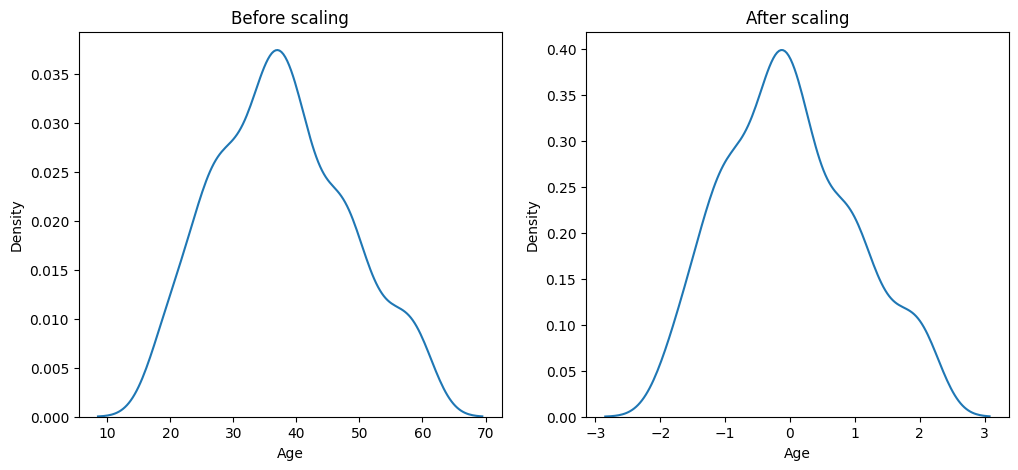

In [76]:
# age column distribution before and after scaling
import matplotlib.pyplot as plt
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5))
sns.kdeplot(df['Age'], ax = ax1)
ax1.set_title('Before scaling')
sns.kdeplot(X_train_scale['Age'], ax = ax2)
ax2.set_title('After scaling')
plt.show()

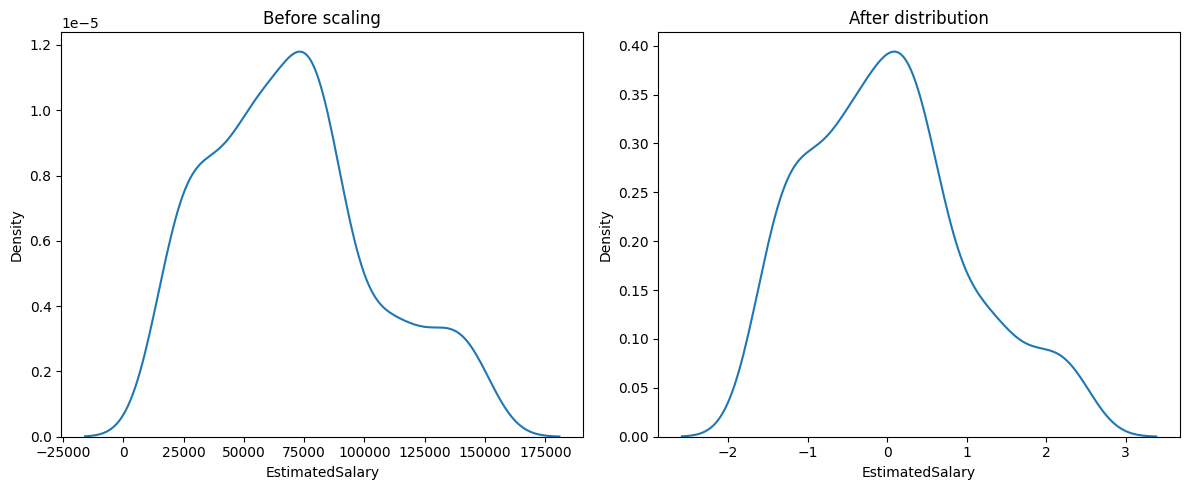

In [79]:
# now for salary
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))
sns.kdeplot(df['EstimatedSalary'], ax = ax1)
ax1.set_title('Before scaling')
sns.kdeplot(X_train_scale['EstimatedSalary'], ax = ax2)
ax2.set_title('After distribution')
plt.tight_layout()
plt.show()

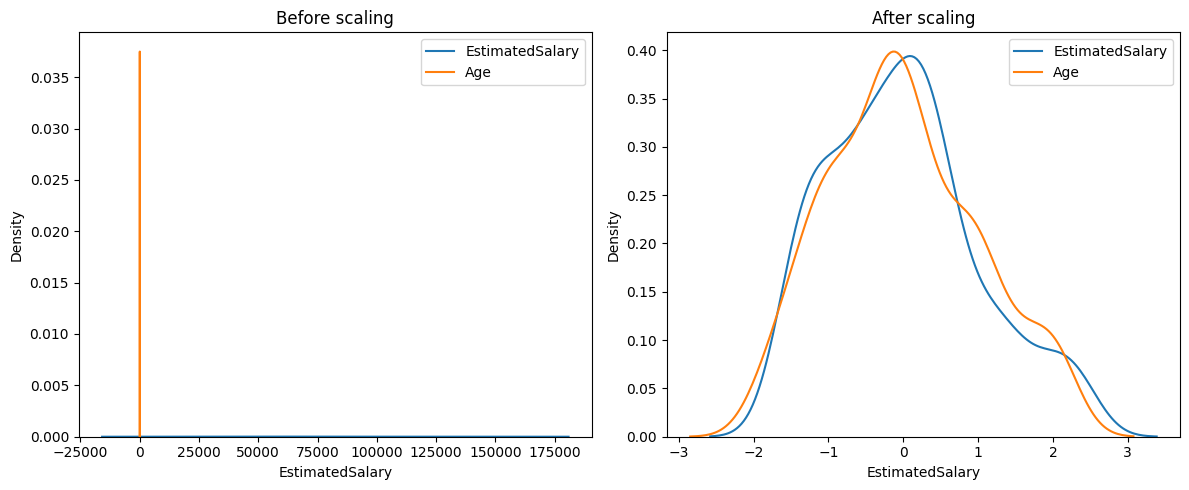

In [86]:
# now we will see both combined ones
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))
sns.kdeplot(df['EstimatedSalary'], ax = ax1, label = 'EstimatedSalary')
sns.kdeplot(df['Age'], ax = ax1, label = 'Age')
ax1.set_title('Before scaling')
ax1.legend()

sns.kdeplot(X_train_scale['EstimatedSalary'], ax = ax2, label = 'EstimatedSalary')
sns.kdeplot(X_train_scale['Age'], ax = ax2, label = 'Age')
ax2.set_title('After scaling')
ax2.legend()

plt.tight_layout()
plt.show()

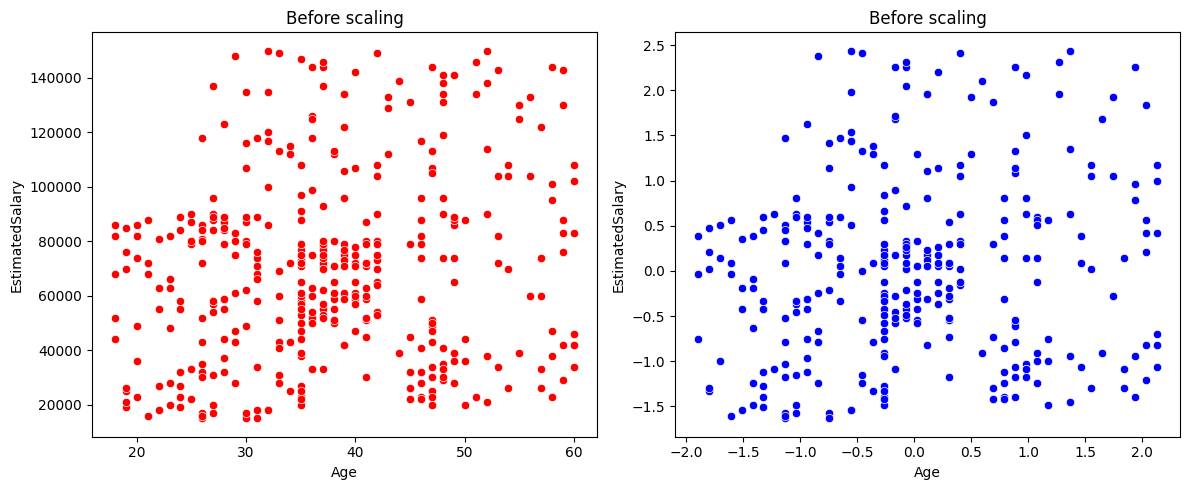

In [88]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

sns.scatterplot(data = df, x = 'Age', y = 'EstimatedSalary', color = 'red', ax = ax1)
ax1.set_title('Before scaling')

sns.scatterplot(data = X_train_scale, x = 'Age', y = 'EstimatedSalary', color = 'blue', ax = ax2)
ax2.set_title('Before scaling')

plt.tight_layout()
plt.show()